In [1]:
import os
import random
from itertools import product
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from aeon.classification.convolution_based import MiniRocketClassifier
from aeon.classification.sklearn import SklearnClassifierWrapper
from aeon.datasets.tsc_datasets import univariate
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

import polars as pl
from sklearn.metrics import accuracy_score

from autotsc.utils import load_dataset
from time import perf_counter

import numpy as np
import polars as pl
import ray
from aeon.classification.dictionary_based import REDCOMETS
from aeon.classification.interval_based import SupervisedTimeSeriesForest

from aeon.classification.base import BaseClassifier
from aeon.classification.convolution_based import (
    MiniRocketClassifier,
    MultiRocketClassifier,
    RocketClassifier,
)
from aeon.classification.dummy import DummyClassifier
from aeon.classification.feature_based import (
    Catch22Classifier,
    SummaryClassifier,
)
from aeon.classification.interval_based import (
    QUANTClassifier,
)
from aeon.classification.sklearn import SklearnClassifierWrapper
from aeon.pipeline import make_pipeline as aeon_make_pipeline
from aeon.transformations.collection import DownsampleTransformer
from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
import types
from autotsc.models import RidgeClassifierCVWithProba
from aeon.classification.convolution_based import HydraClassifier
from autotsc import transformers, utils
from aeon.classification.dictionary_based import IndividualBOSS
from aeon.classification.interval_based import (
    RSTSF,
    CanonicalIntervalForestClassifier,
    DrCIFClassifier,
    QUANTClassifier,
    RandomIntervalSpectralEnsembleClassifier,
    SupervisedTimeSeriesForest,
    TimeSeriesForestClassifier,
)
from aeon.classification.interval_based import RSTSF
from aeon.classification.dictionary_based import WEASEL_V2
from joblib import Parallel, delayed
import numpy as np


from autotsc import utils

2025-11-20 11:13:36.320681: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from sklearn.model_selection import StratifiedKFold

def get_folds(X, y, n_splits=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True)
    folds = []
    for train_idx, val_idx in skf.split(X, y):
        folds.append((train_idx.tolist(), val_idx.tolist()))
    return folds

In [3]:
class CrossValidationWrapper(BaseClassifier):
    def __init__(self, model):
        self.model = model
        self.trained_models_ = []
        super().__init__()

    def _fit(self, X, y):
        pass

    def _predict(self, X):
        all_proba = [m.predict_proba(X) for m in self.trained_models_]
        mean_proba = np.mean(all_proba, axis=0)
        return self.classes_[np.argmax(mean_proba, axis=1)]

    def _fit_predict_proba(self, X, y, cv_splits):
        self.fit(X, y)
        oof_proba = np.zeros((len(y), len(np.unique(y))))

        for train_idx, val_idx in cv_splits:
            model = clone(self.model)
            model.fit(X[train_idx], y[train_idx])
            self.trained_models_.append(model)
            oof_proba[val_idx] = model.predict_proba(X[val_idx])
        return oof_proba
    
    def _fit_predict(self, X, y, cv_splits):
        proba = self.fit_predict_proba(X=X, y=y, cv_splits=cv_splits)
        return self.classes_[np.argmax(proba, axis=1)]

In [4]:
def get_model(name, size=None, n_jobs=4, random_state=42):
    match (size, name.lower()):
        case ('xs', 'catch22'):
            return CrossValidationWrapper(Catch22Classifier(n_jobs=n_jobs, random_state=random_state, estimator=RandomForestClassifier(n_estimators=10, n_jobs=n_jobs)))
        case ('s', 'catch22'):
            return CrossValidationWrapper(Catch22Classifier(n_jobs=n_jobs, random_state=random_state, estimator=RandomForestClassifier(n_estimators=70, n_jobs=n_jobs)))
        case ('m', 'catch22'):
            return CrossValidationWrapper(Catch22Classifier(n_jobs=n_jobs, random_state=random_state, estimator=RandomForestClassifier(n_estimators=200, n_jobs=n_jobs)))
        case ('l', 'catch22'):
            return CrossValidationWrapper(Catch22Classifier(n_jobs=n_jobs, random_state=random_state, estimator=RandomForestClassifier(n_estimators=500, n_jobs=n_jobs)))
        case ('xl', 'catch22'):
            return CrossValidationWrapper(Catch22Classifier(n_jobs=n_jobs, random_state=random_state, estimator=RandomForestClassifier(n_estimators=1000, n_jobs=n_jobs)))
        case (None, 'catch22'):
            return Catch22Classifier(n_jobs=n_jobs, random_state=random_state)
        # case ('xs', RocketClassifier)
        case _:
            return "Invalid size"

In [5]:
m = get_model('Catch22', size='m', n_jobs=4, random_state=42)
m

,model,Catch22Classi...ndom_state=42)
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True


In [ ]:
write_dir = "experiments/automl_ca_vs_time_correlation"
os.makedirs(write_dir, exist_ok=True)

datasets = list(univariate)
random.shuffle(datasets)

rng = random.Random()
rng.shuffle(datasets)
datasets = datasets
print(datasets)
model_types = ["catch22"]

n_jobs = 12
n_runs = 10

['Symbols', 'Mallat', 'ProximalPhalanxOutlineAgeGroup', 'Lightning2', 'BME', 'GunPoint', 'GestureMidAirD1', 'Lightning7', 'ECGFiveDays', 'Wafer', 'Earthquakes', 'UMD', 'ACSF1', 'ECG200', 'InlineSkate', 'DodgerLoopDay', 'InsectEPGSmallTrain', 'AllGestureWiimoteZ', 'FaceFour', 'Fish', 'PigArtPressure', 'Fungi', 'EthanolLevel', 'CBF', 'UWaveGestureLibraryZ', 'GunPointMaleVersusFemale', 'SonyAIBORobotSurface1', 'DistalPhalanxTW', 'ProximalPhalanxTW', 'UWaveGestureLibraryAll', 'PigAirwayPressure', 'Coffee', 'PhalangesOutlinesCorrect', 'GesturePebbleZ1', 'SwedishLeaf', 'NonInvasiveFetalECGThorax2', 'Yoga', 'Worms', 'Trace', 'SmallKitchenAppliances', 'Meat', 'AllGestureWiimoteY', 'UWaveGestureLibraryY', 'SemgHandSubjectCh2', 'FacesUCR', 'MedicalImages', 'Herring', 'Adiac', 'Crop', 'Rock', 'Chinatown', 'StarLightCurves', 'Car', 'InsectEPGRegularTrain', 'Computers', 'ItalyPowerDemand', 'GesturePebbleZ2', 'ShapeletSim', 'MixedShapesSmallTrain', 'OliveOil', 'PowerCons', 'ToeSegmentation1', 'FordB

In [7]:
def process(ds, run, model_name, size):
    try:
        print('Started: ', ds, run, model_name, size)
        m = get_model(name=model_name, size=size, n_jobs=n_jobs, random_state=run)
        full_model_name = f"{size}-{model_name}" if size is not None else model_name
        stats = {
            "dataset": ds,
            "run": run,
            "model": full_model_name,
        }

        hash_val = pl.DataFrame([stats]).hash_rows(seed=42, seed_1=1, seed_2=2, seed_3=3).item()
        file = f"{write_dir}/{hash_val}.parquet"

        if os.path.exists(file):
            return
        else:
            pass

        X_train, y_train, X_test, y_test = utils.load_dataset(ds)
        folds = get_folds(X_train, y_train, n_splits=10)

        fit_predict_cv_exists = hasattr(m, "fit_predict") and callable(getattr(m, "fit_predict"))
        val_acc = None
        start_time = perf_counter()
        if fit_predict_cv_exists:
            y_pred = m.fit_predict(X=X_train, y=y_train, cv_splits=folds)
            val_acc = accuracy_score(y_train, y_pred)
        else:
            m.fit(X_train, y_train)
            y_pred = m.predict(X_train)
        
        end_time = perf_counter()
        test_acc = accuracy_score(y_test, m.predict(X_test))
        train_time = end_time - start_time

        stats["test_accuracy"] = test_acc
        stats["training_time"] = train_time
        stats["val_accuracy"] = val_acc

        df_stat = pl.DataFrame([stats])
        df_stat.write_parquet(file)

        print(f"Completed: Dataset={ds}, Run={run}, Model={full_model_name}")
    except Exception as e:
        print(f"Error processing Dataset={ds}, Run={run}, Model={full_model_name}: {e}")
        pass

    
jobs = []
all_combinations = list(product(datasets, range(n_runs), model_types))
for ds, run, model_name in all_combinations:
    for size in [None, 'xs', 's', 'm', 'l', 'xl']:
        jobs.append(delayed(process)(ds, run, model_name, size))
r = Parallel(n_jobs=16, backend='threading')(jobs)

Started:  Symbols 0 catch22 None
Started:  Symbols 0 catch22 xs
Started:  Symbols 0 catch22 s
Started:  Symbols 0 catch22 m
Started:  Symbols 0 catch22 l
Started:  Symbols 0 catch22 xl
Started:  Symbols 1 catch22 None
Started:  Symbols 1 catch22 xs
Started:  Symbols 1 catch22 s
Started:  Symbols 1 catch22 m
Started:  Symbols 1 catch22 l
Started:  Symbols 1 catch22 xl
Started:  Symbols 2 catch22 None
Started:  Symbols 2 catch22 xs
Started:  Symbols 2 catch22 s
Started:  Symbols 2 catch22 m
Error processing Dataset=Symbols, Run=1, Model=xs-catch22: n_splits=10 cannot be greater than the number of members in each class.
Started:  Symbols 2 catch22 l
Error processing Dataset=Symbols, Run=1, Model=xl-catch22: n_splits=10 cannot be greater than the number of members in each class.
Started:  Symbols 2 catch22 xl
Error processing Dataset=Symbols, Run=0, Model=xl-catch22: n_splits=10 cannot be greater than the number of members in each class.
Started:  Symbols 3 catch22 None
Error processing Da

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selectio

Error processing Dataset=Phoneme, Run=2, Model=s-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  Phoneme 2 catch22 l
Error processing Dataset=Phoneme, Run=0, Model=s-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  Phoneme 2 catch22 xl
Error processing Dataset=Phoneme, Run=2, Model=xs-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  Phoneme 3 catch22 None
Error processing Dataset=Phoneme, Run=0, Model=xs-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  Phoneme 3 catch22 xs
Error processing Dataset=Phoneme, Run=1, Model=xs-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  Phoneme 3 catch22 s
Error processing Dataset=Phoneme

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=0, Model=catch22: All classes must have at least 2 values to run the _fit_predict cross-validation.
Started:  FiftyWords 0 catch22 s


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=Phoneme, Run=3, Model=s-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 0 catch22 m


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=Phoneme, Run=3, Model=xs-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 0 catch22 l


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selectio

Error processing Dataset=Phoneme, Run=4, Model=xs-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 0 catch22 xl
Error processing Dataset=Phoneme, Run=3, Model=catch22: All classes must have at least 2 values to run the _fit_predict cross-validation.
Started:  FiftyWords 1 catch22 None
Error processing Dataset=Phoneme, Run=3, Model=m-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 1 catch22 xs
Error processing Dataset=Phoneme, Run=4, Model=s-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 1 catch22 s
Error processing Dataset=Phoneme, Run=2, Model=l-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 1 catch22 m


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=Phoneme, Run=4, Model=m-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 1 catch22 l
Error processing Dataset=Phoneme, Run=4, Model=catch22: All classes must have at least 2 values to run the _fit_predict cross-validation.
Started:  FiftyWords 1 catch22 xl
Error processing Dataset=FiftyWords, Run=0, Model=xs-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 2 catch22 None
Error processing Dataset=Phoneme, Run=3, Model=l-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 2 catch22 xs
Error processing Dataset=Phoneme, Run=4, Model=l-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 2 catch22 s
Error processing Dataset=Phoneme, Run=2,

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=Phoneme, Run=3, Model=xl-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 2 catch22 l


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=Phoneme, Run=4, Model=xl-catch22: shape mismatch: value array of shape (22,38) could not be broadcast to indexing result of shape (22,39)
Started:  FiftyWords 2 catch22 xl


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selectio

Error processing Dataset=FiftyWords, Run=1, Model=catch22: All classes must have at least 2 values to run the _fit_predict cross-validation.
Started:  FiftyWords 3 catch22 None


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=2, Model=catch22: All classes must have at least 2 values to run the _fit_predict cross-validation.
Started:  FiftyWords 3 catch22 xs


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=0, Model=s-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 3 catch22 s
Error processing Dataset=FiftyWords, Run=1, Model=xs-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 3 catch22 m
Error processing Dataset=FiftyWords, Run=1, Model=s-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 3 catch22 l
Error processing Dataset=FiftyWords, Run=2, Model=xs-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 3 catch22 xl


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=2, Model=s-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 4 catch22 None


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=0, Model=m-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 4 catch22 xs


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=1, Model=m-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 4 catch22 s
Error processing Dataset=FiftyWords, Run=3, Model=catch22: All classes must have at least 2 values to run the _fit_predict cross-validation.
Started:  FiftyWords 4 catch22 m


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=2, Model=m-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 4 catch22 l


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=3, Model=xs-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  FiftyWords 4 catch22 xl


/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=4, Model=catch22: All classes must have at least 2 values to run the _fit_predict cross-validation.
Started:  TwoPatterns 0 catch22 None
Started:  TwoPatterns 0 catch22 xs
Started:  TwoPatterns 0 catch22 s
Started:  TwoPatterns 0 catch22 m
Started:  TwoPatterns 0 catch22 l
Started:  TwoPatterns 0 catch22 xl
Started:  TwoPatterns 1 catch22 None
Started:  TwoPatterns 1 catch22 xs
Started:  TwoPatterns 1 catch22 s
Started:  TwoPatterns 1 catch22 m
Started:  TwoPatterns 1 catch22 l
Started:  TwoPatterns 1 catch22 xl
Started:  TwoPatterns 2 catch22 None
Started:  TwoPatterns 2 catch22 xs
Started:  TwoPatterns 2 catch22 s
Started:  TwoPatterns 2 catch22 m
Started:  TwoPatterns 2 catch22 l
Started:  TwoPatterns 2 catch22 xl
Started:  TwoPatterns 3 catch22 None
Started:  TwoPatterns 3 catch22 xs
Started:  TwoPatterns 3 catch22 s
Started:  TwoPatterns 3 catch22 m
Started:  TwoPatterns 3 catch22 l
Started:  TwoPatterns 3 catch22 xl
Started:  TwoPatterns 4

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=0, Model=l-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  PickupGestureWiimoteZ 0 catch22 m
Error processing Dataset=PickupGestureWiimoteZ, Run=0, Model=xs-catch22: n_splits=10 cannot be greater than the number of members in each class.
Started:  PickupGestureWiimoteZ 0 catch22 l
Error processing Dataset=PickupGestureWiimoteZ, Run=0, Model=s-catch22: n_splits=10 cannot be greater than the number of members in each class.
Started:  PickupGestureWiimoteZ 0 catch22 xl
Error processing Dataset=PickupGestureWiimoteZ, Run=0, Model=l-catch22: n_splits=10 cannot be greater than the number of members in each class.Error processing Dataset=PickupGestureWiimoteZ, Run=0, Model=m-catch22: n_splits=10 cannot be greater than the number of members in each class.
Started:  PickupGestureWiimoteZ 1 catch22 None

Started:  PickupGestureWiimoteZ 1 catch22 xs
Error processing Dataset=PickupGe

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Error processing Dataset=FiftyWords, Run=4, Model=xs-catch22: shape mismatch: value array of shape (45,49) could not be broadcast to indexing result of shape (45,50)
Started:  PickupGestureWiimoteZ 2 catch22 m
Error processing Dataset=PickupGestureWiimoteZ, Run=2, Model=xs-catch22: n_splits=10 cannot be greater than the number of members in each class.Error processing Dataset=PickupGestureWiimoteZ, Run=2, Model=s-catch22: n_splits=10 cannot be greater than the number of members in each class.
Started:  PickupGestureWiimoteZ 2 catch22 l

Started:  PickupGestureWiimoteZ 2 catch22 xl
Error processing Dataset=PickupGestureWiimoteZ, Run=2, Model=catch22: n_splits=10 cannot be greater than the number of members in each class.
Started:  PickupGestureWiimoteZ 3 catch22 None
Error processing Dataset=PickupGestureWiimoteZ, Run=2, Model=m-catch22: n_splits=10 cannot be greater than the number of members in each class.
Started:  PickupGestureWiimoteZ 3 catch22 xs
Error processing Dataset=FiftyWord

In [8]:
df = pl.read_parquet(f"{write_dir}/*.parquet")#.filter(pl.col("dataset").is_in(datasets))
df

dataset,run,model,test_accuracy,training_time,val_accuracy
str,i64,str,f64,f64,f64
"""Plane""",5,"""s-catch22""",1.0,1.875209,0.961905
"""BirdChicken""",4,"""xl-catch22""",0.9,12.764038,0.9
"""InlineSkate""",1,"""m-catch22""",0.434545,3.621297,0.45
"""OliveOil""",0,"""xs-catch22""",0.766667,0.544622,0.666667
"""GunPoint""",6,"""catch22""",0.933333,2.833602,0.92
…,…,…,…,…,…
"""HandOutlines""",3,"""xs-catch22""",0.862162,105.487453,0.841
"""MoteStrain""",6,"""l-catch22""",0.866613,6.616562,0.75
"""GunPointOldVersusYoung""",2,"""l-catch22""",1.0,42.696947,1.0


In [9]:
stats_pivot = df.pivot(values="test_accuracy", index="dataset", columns="model", aggregate_function='mean').drop_nulls()
stats_pivot

/tmp/ipykernel_1742971/1711859027.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  stats_pivot = df.pivot(values="test_accuracy", index="dataset", columns="model", aggregate_function='mean').drop_nulls()


dataset,s-catch22,xl-catch22,m-catch22,xs-catch22,catch22,l-catch22
str,f64,f64,f64,f64,f64,f64
"""Plane""",1.0,1.0,1.0,0.985034,0.994558,1.0
"""BirdChicken""",0.885714,0.864286,0.871429,0.878571,0.871429,0.871429
"""InlineSkate""",0.432182,0.428545,0.428909,0.413818,0.429273,0.428727
"""OliveOil""",0.738095,0.761905,0.761905,0.72381,0.742857,0.766667
"""GunPoint""",0.946667,0.942667,0.946,0.925333,0.947333,0.943333
…,…,…,…,…,…,…
"""Herring""",0.544643,0.553571,0.537946,0.537946,0.526786,0.551339
"""ECGFiveDays""",0.766551,0.760411,0.76373,0.748631,0.779658,0.759914
"""UMD""",0.877976,0.868056,0.87004,0.87004,0.872024,0.87004


In [10]:
models = df["model"].unique().to_list()
P = stats_pivot.select(models).to_numpy()

(<Figure size 600x250 with 1 Axes>, <Axes: >)

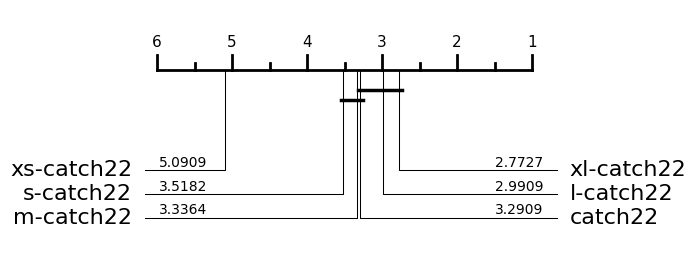

In [11]:
from aeon.visualisation import plot_critical_difference

plot_critical_difference(P, models)